# Building Transparent Loan Approval Prediction System

## 1. Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv('LoanPredictionProblemDataset.csv')
print(df.shape)
df.head()

(981, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 2. Exploratory Data Analysis (EDA)

In [2]:
print(df.info())
print('\nMissing Values:\n', df.isnull().sum())
print('\nDescriptive Stats:\n')
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            981 non-null    object 
 1   Gender             957 non-null    object 
 2   Married            978 non-null    object 
 3   Dependents         956 non-null    object 
 4   Education          981 non-null    object 
 5   Self_Employed      926 non-null    object 
 6   ApplicantIncome    981 non-null    int64  
 7   CoapplicantIncome  981 non-null    float64
 8   LoanAmount         954 non-null    float64
 9   Loan_Amount_Term   961 non-null    float64
 10  Credit_History     902 non-null    float64
 11  Property_Area      981 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 99.8+ KB
None

Missing Values:
 Loan_ID                0
Gender                24
Married                3
Dependents    

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,981.000000,981.000000,954.000000,961.000000,902.000000
mean,5179.795107,1601.916330,142.511530,342.201873,0.835920
std,5695.104533,2718.772806,77.421743,65.100602,0.370553
min,0.000000,0.000000,9.000000,6.000000,0.000000
25%,2875.000000,0.000000,100.000000,360.000000,1.000000
50%,3800.000000,1110.000000,126.000000,360.000000,1.000000
75%,5516.000000,2365.000000,162.000000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


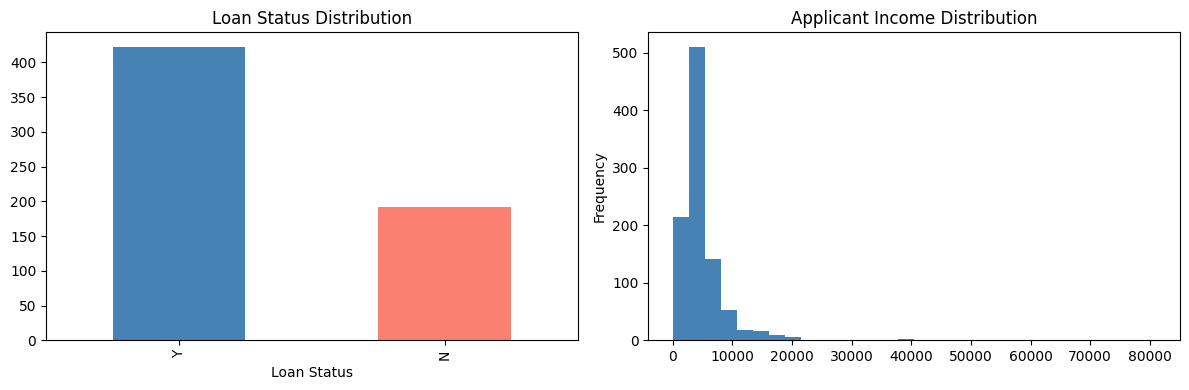

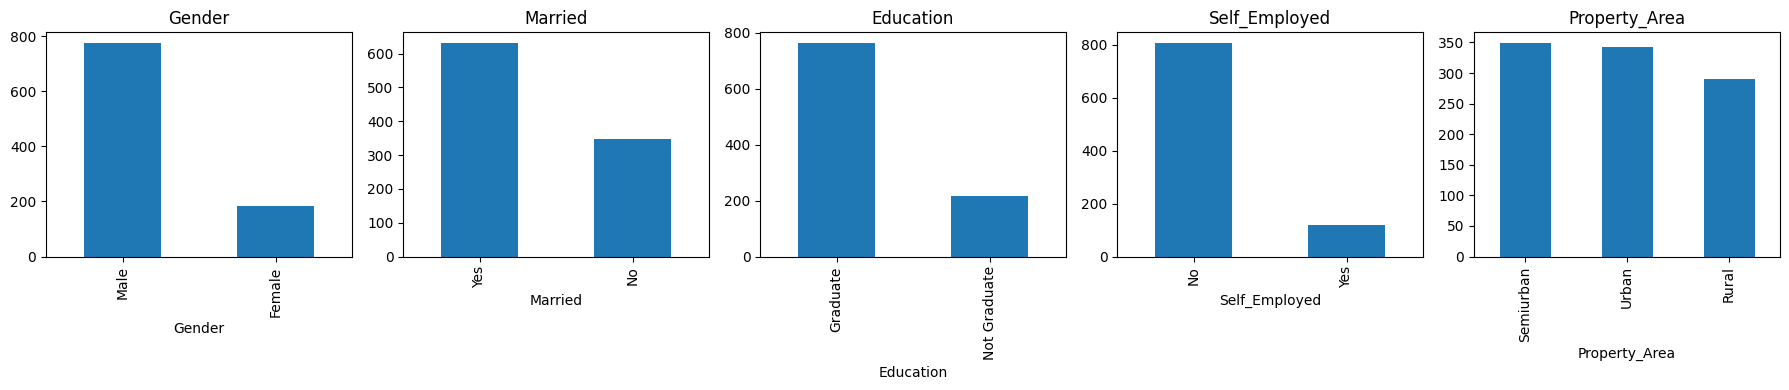

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Loan_Status'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','salmon'])
axes[0].set_title('Loan Status Distribution')
axes[0].set_xlabel('Loan Status')

df['ApplicantIncome'].plot(kind='hist', bins=30, ax=axes[1], color='steelblue')
axes[1].set_title('Applicant Income Distribution')

plt.tight_layout()
plt.show()

cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']
fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 4))
for ax, col in zip(axes, cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 3. Data Cleaning

### 4.1 Handle Missing Values

In [4]:
df.drop(columns=['Loan_ID'], inplace=True)

cat_fill = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History', 'Loan_Amount_Term']
for col in cat_fill:
    df[col] = df[col].fillna(df[col].mode()[0])

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df = df.dropna(subset=['Loan_Status'])

print('Missing values after handling:\n', df.isnull().sum())

Missing values after handling:
 Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


### Fix Incorrect Values

In [5]:
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

df['ApplicantIncome'] = df['ApplicantIncome'].clip(lower=0)
df['CoapplicantIncome'] = df['CoapplicantIncome'].clip(lower=0)

print(df['Dependents'].value_counts())
print(df[['ApplicantIncome','CoapplicantIncome']].describe())

Dependents
0    360
1    102
2    101
3     51
Name: count, dtype: int64
       ApplicantIncome  CoapplicantIncome
count       614.000000         614.000000
mean       5403.459283        1621.245798
std        6109.041673        2926.248369
min         150.000000           0.000000
25%        2877.500000           0.000000
50%        3812.500000        1188.500000
75%        5795.000000        2297.250000
max       81000.000000       41667.000000


## 4. Encoding Categorical Data

In [6]:
le = LabelEncoder()

binary_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Loan_Status']
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)

print(df.dtypes)
df.head()

Gender                       int64
Married                      int64
Dependents                   int64
Education                    int64
Self_Employed                int64
ApplicantIncome              int64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Credit_History             float64
Loan_Status                  int64
Property_Area_Semiurban       bool
Property_Area_Urban           bool
dtype: object


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,0,5849,0.0,126.0,360.0,1.0,1,False,True
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,False,False
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,1,False,True
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,1,False,True
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,1,False,True


## 5. Feature Engineering

In [7]:
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['EMI'] = df['LoanAmount'] / df['Loan_Amount_Term']
df['IncomeToLoan'] = df['TotalIncome'] / (df['LoanAmount'] + 1)

df.drop(columns=['ApplicantIncome', 'CoapplicantIncome'], inplace=True)

print(df[['TotalIncome','EMI','IncomeToLoan']].describe())

        TotalIncome         EMI  IncomeToLoan
count    614.000000  614.000000    614.000000
mean    7024.705081    0.473465     50.673382
std     6458.663872    0.511157     36.917886
min     1442.000000    0.025000     12.042969
25%     4166.000000    0.288889     35.197414
50%     5416.500000    0.361111     41.186551
75%     7521.750000    0.505556     51.727849
max    81000.000000    9.250000    392.010989


## 6. Outlier Removal using IQR

In [8]:
num_cols = ['LoanAmount', 'TotalIncome', 'EMI', 'IncomeToLoan']

before = len(df)
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

print(f'Rows before: {before}, after outlier removal: {len(df)}')

Rows before: 614, after outlier removal: 462


## 7. Feature Scaling — StandardScaler

In [9]:
scale_cols = ['LoanAmount', 'Loan_Amount_Term', 'TotalIncome', 'EMI', 'IncomeToLoan']

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print(df[scale_cols].describe().round(2))

       LoanAmount  Loan_Amount_Term  TotalIncome     EMI  IncomeToLoan
count      462.00            462.00       462.00  462.00        462.00
mean         0.00             -0.00         0.00    0.00          0.00
std          1.00              1.00         1.00    1.00          1.00
min         -2.36             -4.44        -2.12   -2.31         -2.72
25%         -0.70              0.09        -0.74   -0.68         -0.68
50%         -0.09              0.09        -0.15   -0.10         -0.15
75%          0.60              0.09         0.54    0.61          0.61
max          3.13              3.11         3.21    2.92          2.97


## 8. Split Data

In [10]:
X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')
print(f'Train label distribution:\n{y_train.value_counts()}')

Train size: (369, 13), Test size: (93, 13)
Train label distribution:
Loan_Status
1    256
0    113
Name: count, dtype: int64


## 9. Train Random Forest Model

In [11]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8387096774193549
              precision    recall  f1-score   support

           0       0.77      0.69      0.73        29
           1       0.87      0.91      0.89        64

    accuracy                           0.84        93
   macro avg       0.82      0.80      0.81        93
weighted avg       0.84      0.84      0.84        93



---
# Explainable AI and Model Interpretability

## 10. Feature Relevance — Filter Methods
Statistical tests to rank features independently of any model.

                            Chi2   F-Score  Mutual_Info
Feature                                                
Credit_History           15.5209  160.5504       0.1744
Loan_Amount_Term          0.2648    1.0852       0.0476
Property_Area_Urban       0.9515    1.4135       0.0410
IncomeToLoan              0.0019    0.0050       0.0357
Self_Employed             0.5106    0.5688       0.0208
Property_Area_Semiurban   7.6912   12.8123       0.0175
Dependents                0.6245    0.4596       0.0000
Married                   1.1020    3.1621       0.0000
Gender                    0.2230    1.2441       0.0000
Education                 4.6596    6.2334       0.0000
LoanAmount                0.6403    1.5814       0.0000
TotalIncome               1.0256    2.3159       0.0000
EMI                       0.8027    1.9560       0.0000


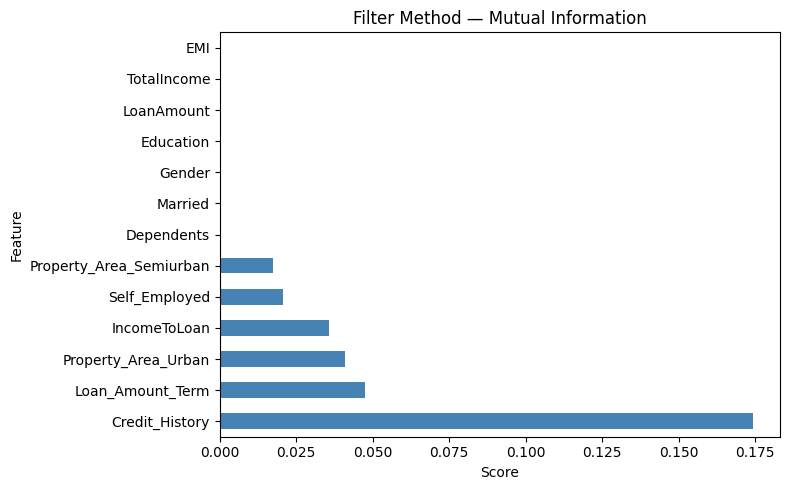

In [12]:
from sklearn.feature_selection import chi2, f_classif, mutual_info_classif


X_pos = X_train.astype(float) - X_train.astype(float).min()

chi2_scores, _ = chi2(X_pos, y_train)
f_scores, _    = f_classif(X_train, y_train)
mi_scores      = mutual_info_classif(X_train, y_train, random_state=42)

filter_df = pd.DataFrame({
    'Feature'  : X_train.columns,
    'Chi2'     : chi2_scores,
    'F-Score'  : f_scores,
    'Mutual_Info': mi_scores
}).set_index('Feature').sort_values('Mutual_Info', ascending=False)

print(filter_df.round(4))

filter_df['Mutual_Info'].plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Filter Method — Mutual Information')
plt.xlabel('Score')
plt.tight_layout()
plt.show()

## 11. Feature Relevance — Wrapper Method (RFE)

                         Selected  Rank
Feature                                
Gender                       True     1
Married                      True     1
Education                    True     1
Credit_History               True     1
Loan_Amount_Term             True     1
Property_Area_Semiurban      True     1
TotalIncome                 False     2
EMI                         False     3
IncomeToLoan                False     4
Self_Employed               False     5
Dependents                  False     6
LoanAmount                  False     7
Property_Area_Urban         False     8


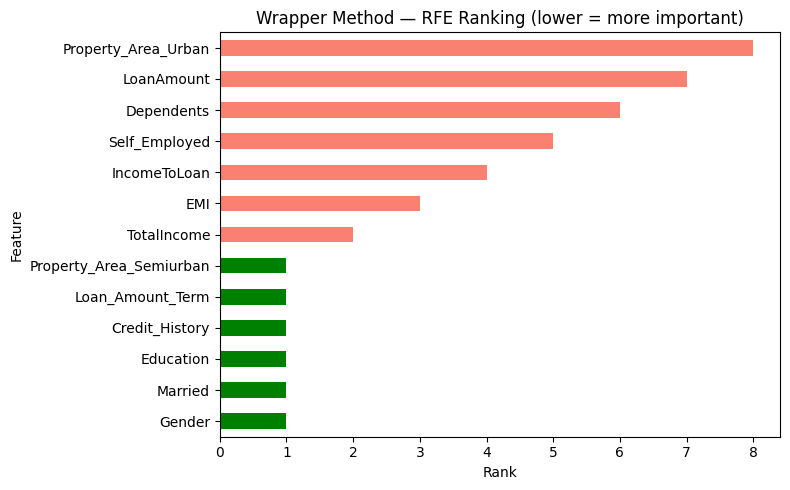

In [13]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(estimator=lr, n_features_to_select=6)
rfe.fit(X_train, y_train)

rfe_df = pd.DataFrame({
    'Feature' : X_train.columns,
    'Selected': rfe.support_,
    'Rank'    : rfe.ranking_
}).set_index('Feature').sort_values('Rank')

print(rfe_df)

colors = ['green' if s else 'salmon' for s in rfe_df['Selected']]
rfe_df['Rank'].plot(kind='barh', figsize=(8, 5), color=colors)
plt.title('Wrapper Method — RFE Ranking (lower = more important)')
plt.xlabel('Rank')
plt.tight_layout()
plt.show()

## 12. Feature Relevance — Embedded Method (Lasso)

Lasso coefficients (absolute):
Credit_History             0.6698
Property_Area_Semiurban    0.1301
Married                    0.0533
Education                  0.0480
Loan_Amount_Term           0.0384
Gender                     0.0252
Dependents                 0.0126
TotalIncome                0.0071
Self_Employed              0.0000
LoanAmount                 0.0000
Property_Area_Urban        0.0000
EMI                        0.0000
IncomeToLoan               0.0000
dtype: float64


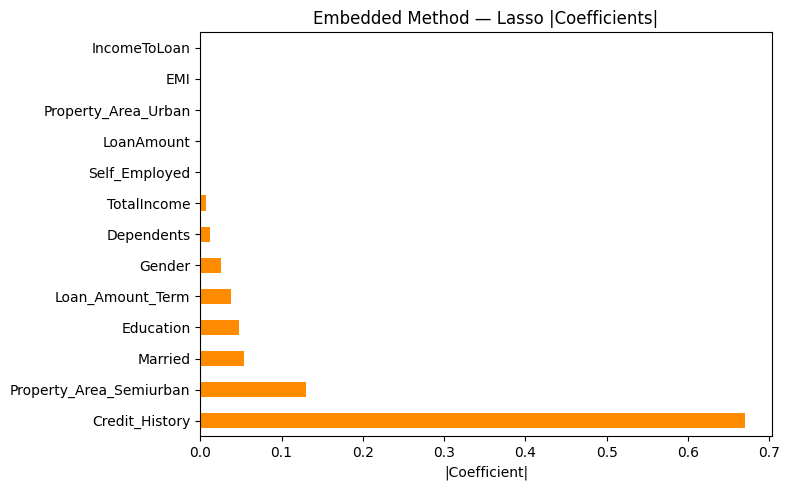

In [14]:
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import SelectFromModel

lasso = LassoCV(cv=5, random_state=42, max_iter=5000)
lasso.fit(X_train, y_train)

lasso_coef = pd.Series(np.abs(lasso.coef_), index=X_train.columns).sort_values(ascending=False)
print('Lasso coefficients (absolute):')
print(lasso_coef.round(4))

lasso_coef.plot(kind='barh', figsize=(8, 5), color='darkorange')
plt.title('Embedded Method — Lasso |Coefficients|')
plt.xlabel('|Coefficient|')
plt.tight_layout()
plt.show()

## 13. Model-Specific Feature Importance (Random Forest)

Random Forest Feature Importances:
Credit_History             0.2501
IncomeToLoan               0.1720
TotalIncome                0.1460
EMI                        0.1149
LoanAmount                 0.1122
Dependents                 0.0392
Property_Area_Semiurban    0.0333
Loan_Amount_Term           0.0305
Education                  0.0239
Married                    0.0231
Gender                     0.0193
Property_Area_Urban        0.0183
Self_Employed              0.0171
dtype: float64


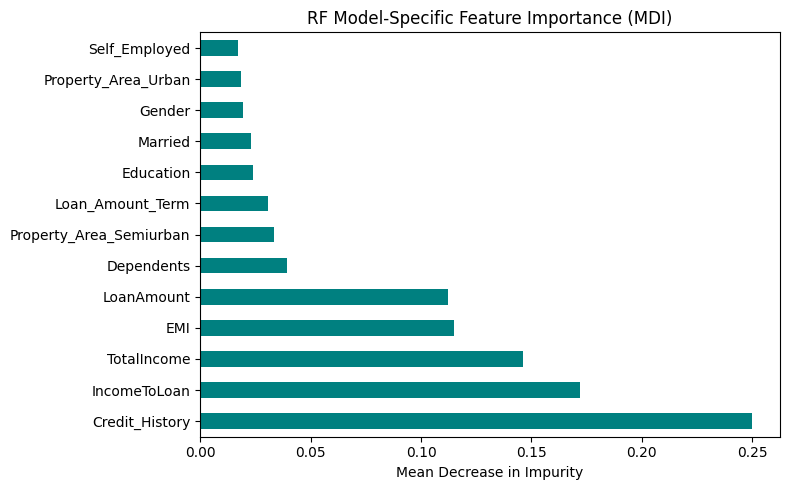

In [15]:
rf_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print('Random Forest Feature Importances:')
print(rf_importance.round(4))

rf_importance.plot(kind='barh', figsize=(8, 5), color='teal')
plt.title('RF Model-Specific Feature Importance (MDI)')
plt.xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

### 13.1 Permutation Importance (model-agnostic variant on test set)

                         Importance_Mean  Importance_Std
Feature                                                 
Credit_History                    0.2545          0.0461
Gender                            0.0104          0.0059
Education                         0.0100          0.0139
TotalIncome                       0.0054          0.0110
LoanAmount                        0.0050          0.0138
Loan_Amount_Term                  0.0036          0.0070
IncomeToLoan                      0.0000          0.0121
Self_Employed                     0.0000          0.0039
EMI                               0.0000          0.0111
Property_Area_Semiurban          -0.0004          0.0076
Dependents                       -0.0022          0.0065
Property_Area_Urban              -0.0075          0.0063
Married                          -0.0115          0.0068


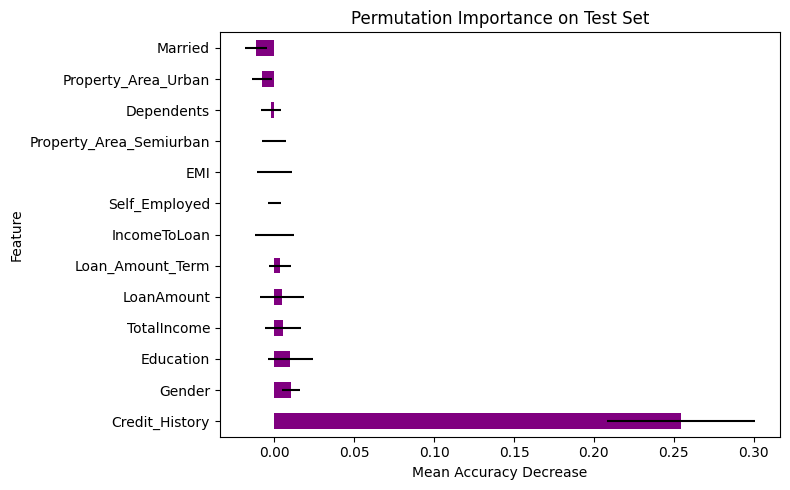

In [16]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(model, X_test, y_test, n_repeats=30, random_state=42)

perm_df = pd.DataFrame({
    'Feature'       : X_test.columns,
    'Importance_Mean': perm.importances_mean,
    'Importance_Std' : perm.importances_std
}).set_index('Feature').sort_values('Importance_Mean', ascending=False)

print(perm_df.round(4))

perm_df['Importance_Mean'].plot(kind='barh', figsize=(8, 5),
                                 xerr=perm_df['Importance_Std'], color='purple')
plt.title('Permutation Importance on Test Set')
plt.xlabel('Mean Accuracy Decrease')
plt.tight_layout()
plt.show()

## 14. Model-Agnostic XAI — SHAP Analysis
Install if needed: `pip install shap`

In [17]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Different SHAP versions return different shapes for classifiers:
# - list: [class0, class1] each (n_samples, n_features)
# - ndarray: (n_samples, n_features, n_classes)
# We always work with the class-1 ("loan approved") attributions as (n_samples, n_features).
if isinstance(shap_values, list):
    sv = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

print("sv shape:", np.asarray(sv).shape)

sv shape: (93, 13)


### 14.1 SHAP Summary Plot (Global)

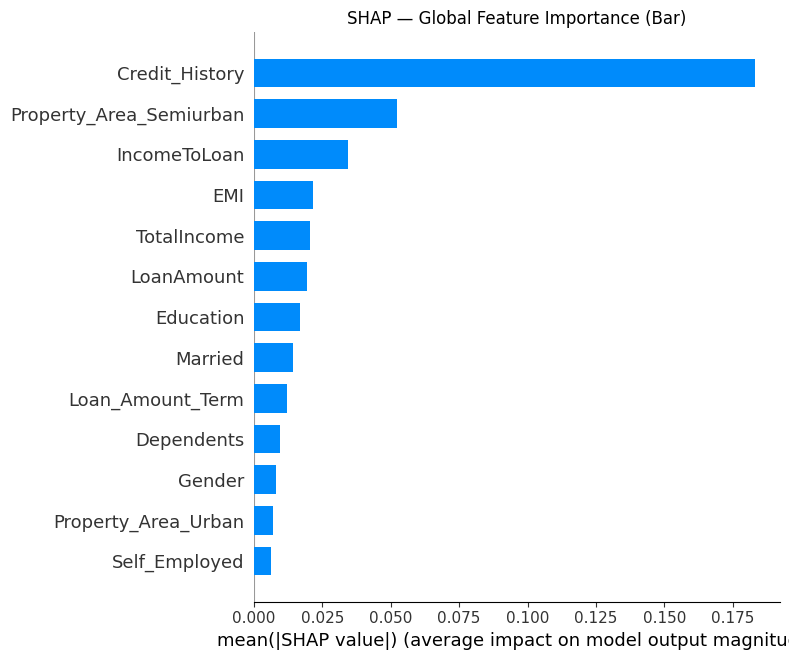

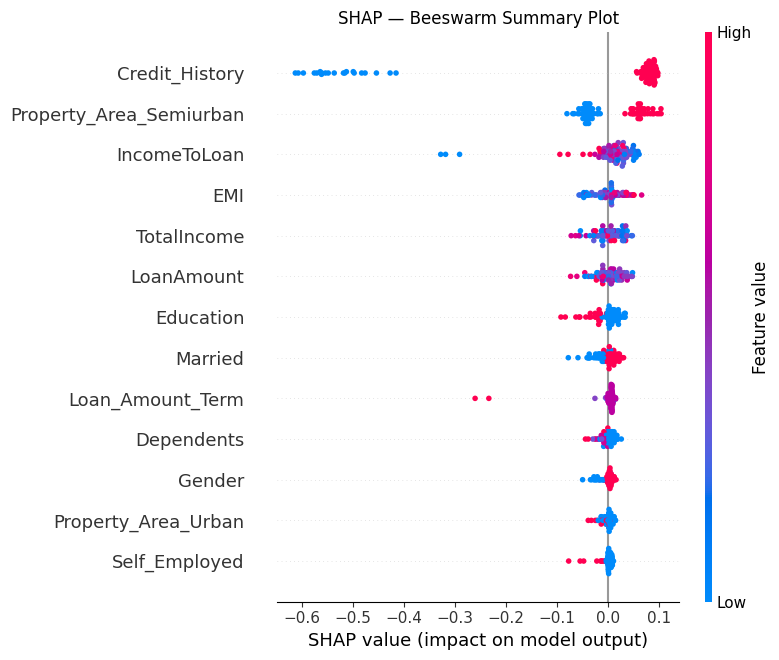

In [18]:
shap.summary_plot(sv, X_test, plot_type='bar', show=False)
plt.title('SHAP — Global Feature Importance (Bar)')
plt.tight_layout()
plt.show()

shap.summary_plot(sv, X_test, show=False)
plt.title('SHAP — Beeswarm Summary Plot')
plt.tight_layout()
plt.show()

### 14.2 SHAP Local Explanation — Single Prediction (Waterfall)

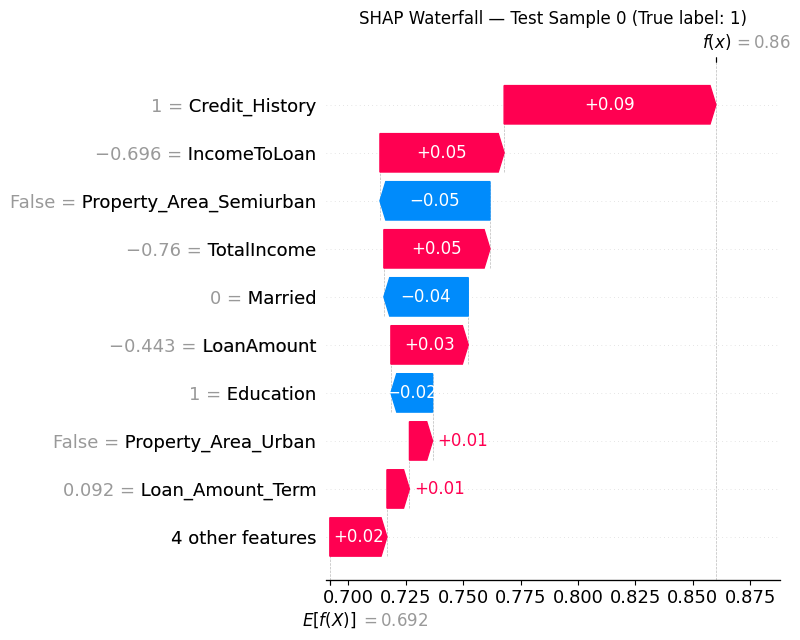

In [19]:
# Explain the first test instance (class-1 / "approved")
idx = 0

base_value = (
    explainer.expected_value[1]
    if isinstance(explainer.expected_value, (list, np.ndarray))
    else explainer.expected_value
 )

shap.plots.waterfall(
    shap.Explanation(
        values=sv[idx],
        base_values=base_value,
        data=X_test.iloc[idx].values,
        feature_names=X_test.columns.tolist(),
    ),
    show=False,
 )

plt.title(f"SHAP Waterfall — Test Sample {idx} (True label: {y_test.iloc[idx]})")
plt.tight_layout()
plt.show()

### 14.3 SHAP Dependence Plot — Top Feature

Top SHAP feature: Credit_History


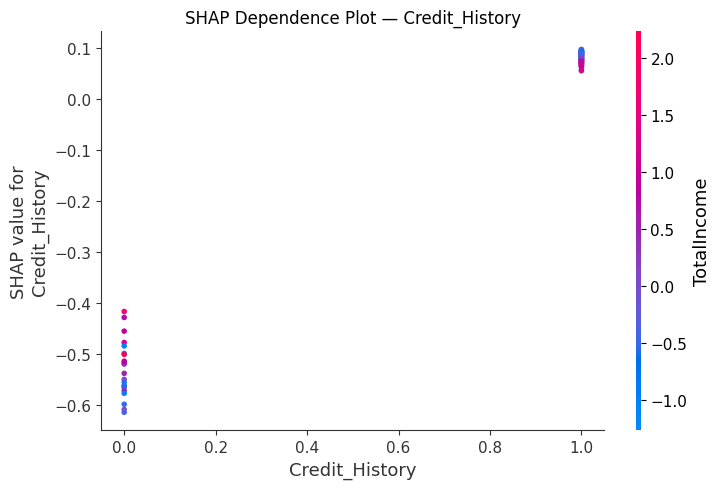

In [20]:
top_feature = pd.Series(np.abs(sv).mean(axis=0), index=X_test.columns).idxmax()
print(f'Top SHAP feature: {top_feature}')

shap.dependence_plot(top_feature, sv, X_test, show=False)
plt.title(f'SHAP Dependence Plot — {top_feature}')
plt.tight_layout()
plt.show()

## 15. Comparative Interpretation and Analysis

                         Mutual_Info  RFE_Rank_inv  Lasso_Coef  RF_MDI  \
Credit_History                 1.000         1.000       1.000   1.000   
Property_Area_Semiurban        0.101         1.000       0.194   0.069   
IncomeToLoan                   0.205         0.143       0.000   0.665   
EMI                            0.000         0.238       0.000   0.420   
TotalIncome                    0.000         0.429       0.011   0.553   
LoanAmount                     0.000         0.020       0.000   0.408   
Education                      0.000         1.000       0.072   0.029   
Married                        0.000         1.000       0.080   0.026   
Loan_Amount_Term               0.273         1.000       0.057   0.058   
Dependents                     0.000         0.048       0.019   0.095   
Gender                         0.000         1.000       0.038   0.009   
Property_Area_Urban            0.235         0.000       0.000   0.005   
Self_Employed                  0.119  

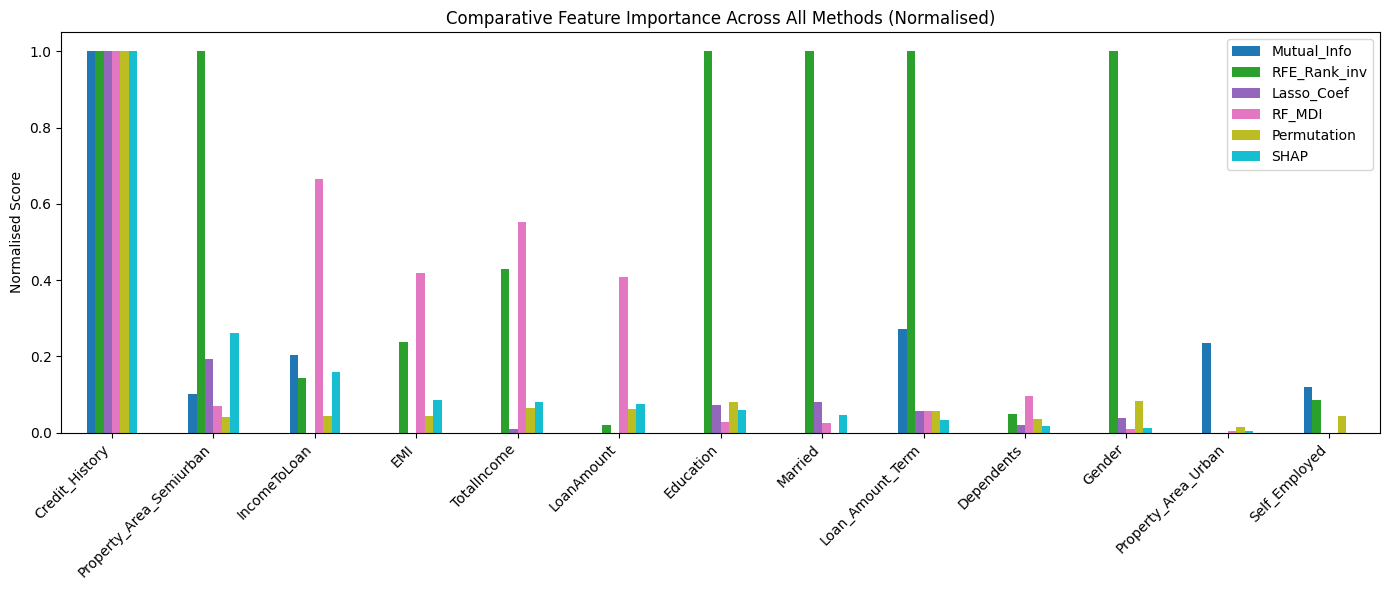

In [21]:
#Compare feature relevance results across different methods
# Normalise each ranking to [0,1] for fair comparison
def normalise(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

shap_mean = pd.Series(np.abs(sv).mean(axis=0), index=X_test.columns)

compare = pd.DataFrame({
    'Mutual_Info'   : normalise(filter_df['Mutual_Info']),
    'RFE_Rank_inv'  : normalise(1 / rfe_df['Rank']),          # invert so higher = more important
    'Lasso_Coef'    : normalise(lasso_coef),
    'RF_MDI'        : normalise(rf_importance),
    'Permutation'   : normalise(perm_df['Importance_Mean']),
    'SHAP'          : normalise(shap_mean)
}).fillna(0).sort_values('SHAP', ascending=False)

print(compare.round(3))

compare.plot(kind='bar', figsize=(14, 6), colormap='tab10')
plt.title('Comparative Feature Importance Across All Methods (Normalised)')
plt.ylabel('Normalised Score')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 15.1 Correlation Heatmap of Rankings

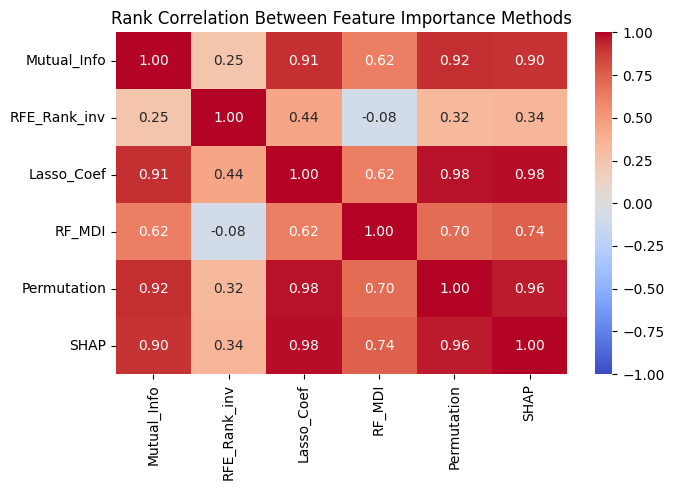

In [22]:
corr = compare.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Rank Correlation Between Feature Importance Methods')
plt.tight_layout()
plt.show()

                         RF_Importance  SHAP_MeanAbs  RF_Normalised  \
Credit_History                  0.2501        0.1832         1.0000   
Property_Area_Semiurban         0.0333        0.0523         0.0694   
IncomeToLoan                    0.1720        0.0342         0.6650   
EMI                             0.1149        0.0214         0.4198   
TotalIncome                     0.1460        0.0205         0.5532   
LoanAmount                      0.1122        0.0193         0.4083   
Education                       0.0239        0.0166         0.0291   
Married                         0.0231        0.0142         0.0259   
Loan_Amount_Term                0.0305        0.0120         0.0577   
Dependents                      0.0392        0.0094         0.0950   
Gender                          0.0193        0.0082         0.0093   
Property_Area_Urban             0.0183        0.0069         0.0051   
Self_Employed                   0.0171        0.0061         0.0000   

     

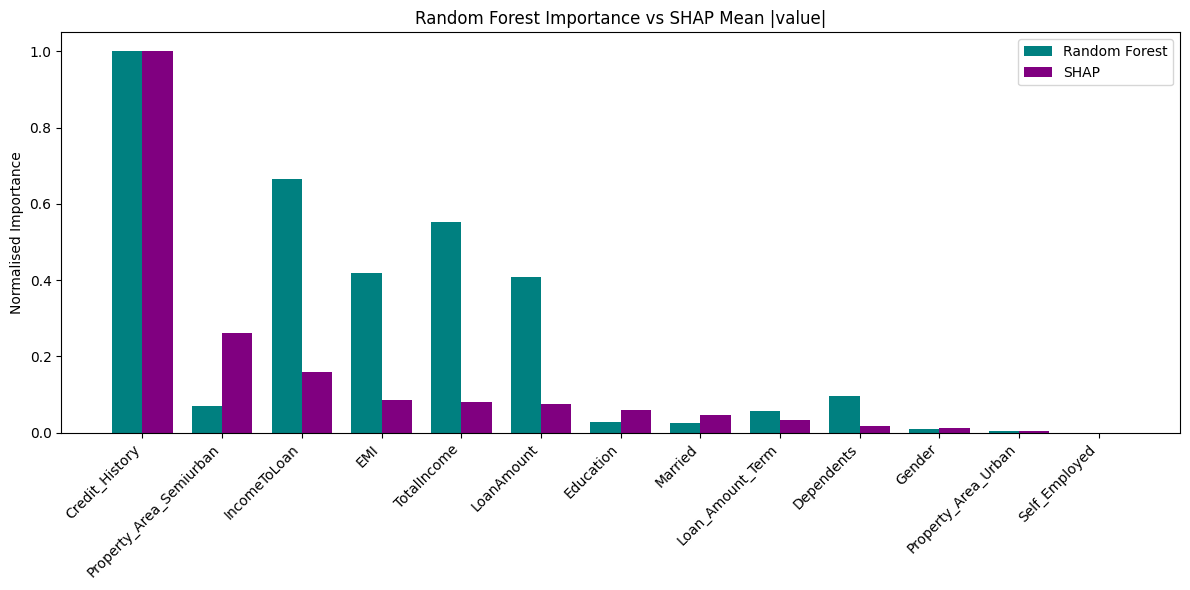

Spearman rank correlation between RF importance and SHAP: 0.846
Top 5 RF features: ['Credit_History', 'IncomeToLoan', 'TotalIncome', 'EMI', 'LoanAmount']
Top 5 SHAP features: ['Credit_History', 'Property_Area_Semiurban', 'IncomeToLoan', 'EMI', 'TotalIncome']
Common top features: ['Credit_History', 'EMI', 'IncomeToLoan', 'TotalIncome']


In [23]:
# Compare model-specific feature importance with SHAP explanations

rf_shap_compare = pd.DataFrame({
    'RF_Importance': rf_importance,
    'SHAP_MeanAbs': shap_mean
}).fillna(0)

# Normalise for easier visual comparison
rf_shap_compare['RF_Normalised'] = (
    rf_shap_compare['RF_Importance'] - rf_shap_compare['RF_Importance'].min()
) / (rf_shap_compare['RF_Importance'].max() - rf_shap_compare['RF_Importance'].min() + 1e-9)

rf_shap_compare['SHAP_Normalised'] = (
    rf_shap_compare['SHAP_MeanAbs'] - rf_shap_compare['SHAP_MeanAbs'].min()
) / (rf_shap_compare['SHAP_MeanAbs'].max() - rf_shap_compare['SHAP_MeanAbs'].min() + 1e-9)

rf_shap_compare = rf_shap_compare.sort_values('SHAP_MeanAbs', ascending=False)

print(rf_shap_compare.round(4))

plt.figure(figsize=(12, 6))
x = np.arange(len(rf_shap_compare))
width = 0.38

plt.bar(x - width/2, rf_shap_compare['RF_Normalised'], width, label='Random Forest', color='teal')
plt.bar(x + width/2, rf_shap_compare['SHAP_Normalised'], width, label='SHAP', color='purple')

plt.xticks(x, rf_shap_compare.index, rotation=45, ha='right')
plt.ylabel('Normalised Importance')
plt.title('Random Forest Importance vs SHAP Mean |value|')
plt.legend()
plt.tight_layout()
plt.show()

spearman_corr = rf_shap_compare['RF_Importance'].corr(rf_shap_compare['SHAP_MeanAbs'], method='spearman')
print(f"Spearman rank correlation between RF importance and SHAP: {spearman_corr:.3f}")

top_rf = rf_importance.head(5).index.tolist()
top_shap = shap_mean.sort_values(ascending=False).head(5).index.tolist()
print("Top 5 RF features:", top_rf)
print("Top 5 SHAP features:", top_shap)
print("Common top features:", sorted(set(top_rf).intersection(top_shap)))